In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [5]:
using Revise
includet("./base.jl")
using SSMCMain.ModifiedMiCRM, SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.TwoMMs, SSMCMain.ModifiedMiCRM.FFTAnalysis

In [7]:
using ProgressMeter
using ColorSchemes
using UnPack
using Base.Threads
using FFTW
using Optim

In [8]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

In [9]:
includet("../../../scripts/single_influx.jl")

# Load data

In [10]:
f = jldopen("./data4.jld2")

fmetadata = f["metadata"]
N = fmetadata.N
M = fmetadata.M
dx = fmetadata.dx
sN = fmetadata.sN
Klips = fmetadata.Klips_to_run

Klips_matrix = Matrix{typeof(Klips[1])}(undef, fmetadata.num_runs, length(Klips))
for ii in 1:length(Klips)
    Klips_matrix[:,ii] .= Ref(Klips[ii])
end;

# second index sets the Klip set, first index the run index
fparams = f["params"]
fode_rcs = f["ode_retcodes"]
fode_fTs = f["ode_final_Ts"]
fode_fss = f["ode_final_states"]
fpde_fTs = f["pde_final_Ts"]
fpde_fss = f["pde_final_states"]
fpde_rcs = f["pde_retcodes"]
fpde_dls = f["pde_dom_length"];

In [35]:
# Make a dataframe with all results
df = DataFrame(;
    K=getindex.(Klips_matrix, 1)[:],
    l=getindex.(Klips_matrix, 2)[:],
    p=getindex.(Klips_matrix, 3)[:],
    params=fparams[:],
    ode_rc=fode_rcs[:],
    ode_fT=fode_fTs[:],
    ode_fs=fode_fss[:],
    pde_rc=fpde_rcs[:],
    pde_fT=fpde_fTs[:],
    pde_fs=fpde_fss[:],
    dl=fpde_dls[:],
    Lmax=map(Klips_matrix) do Klip fr2_Lmax(Klip...) end[:],
);

df.ode_fs_tbiom = map(df.ode_fs) do fs sum(fs[1:N]) end;
df.pde_fs_biom = map(df.pde_fs) do fs get_total_biomass_1d(fs, N) end;
df.pde_fs_tbiom = sum.(df.pde_fs_biom);

@show nrow(df), names(df)

gdf = @subset(df,
    :ode_rc .== ReturnCode.Success,
    :pde_rc .== ReturnCode.Terminated,
    :ode_fs_tbiom .> 1e-9,
    # :pde_fs_tbiom .> 1e-9,
)
nrow(gdf)

(nrow(df), names(df)) = (300, ["K", "l", "p", "params", "ode_rc", "ode_fT", "ode_fs", "pde_rc", "pde_fT", "pde_fs", "dl", "Lmax", "ode_fs_tbiom", "pde_fs_biom", "pde_fs_tbiom"])


234

# Do big disprel

In [36]:
Kgroups = groupby(gdf, :K);

In [137]:
sdf = Kgroups[5];
sdf.K[1]

14.677992676220699

S=4, resid=7.6377e-26, mm_fs[1]=1.9175e-35
S=5, resid=8.1017e-26, mm_fs[1]=-4.7563e-32
S=6, resid=8.4843e-35, mm_fs[1]=-4.553e-37
S=7, resid=2.6636e-26, mm_fs[1]=-1.1056e-32
S=8, resid=1.7754e-26, mm_fs[1]=2.3103e-33
S=9, resid=1.3765e-33, mm_fs[1]=2.2733e-35
S=10, resid=3.1453e-26, mm_fs[1]=1.082e-33


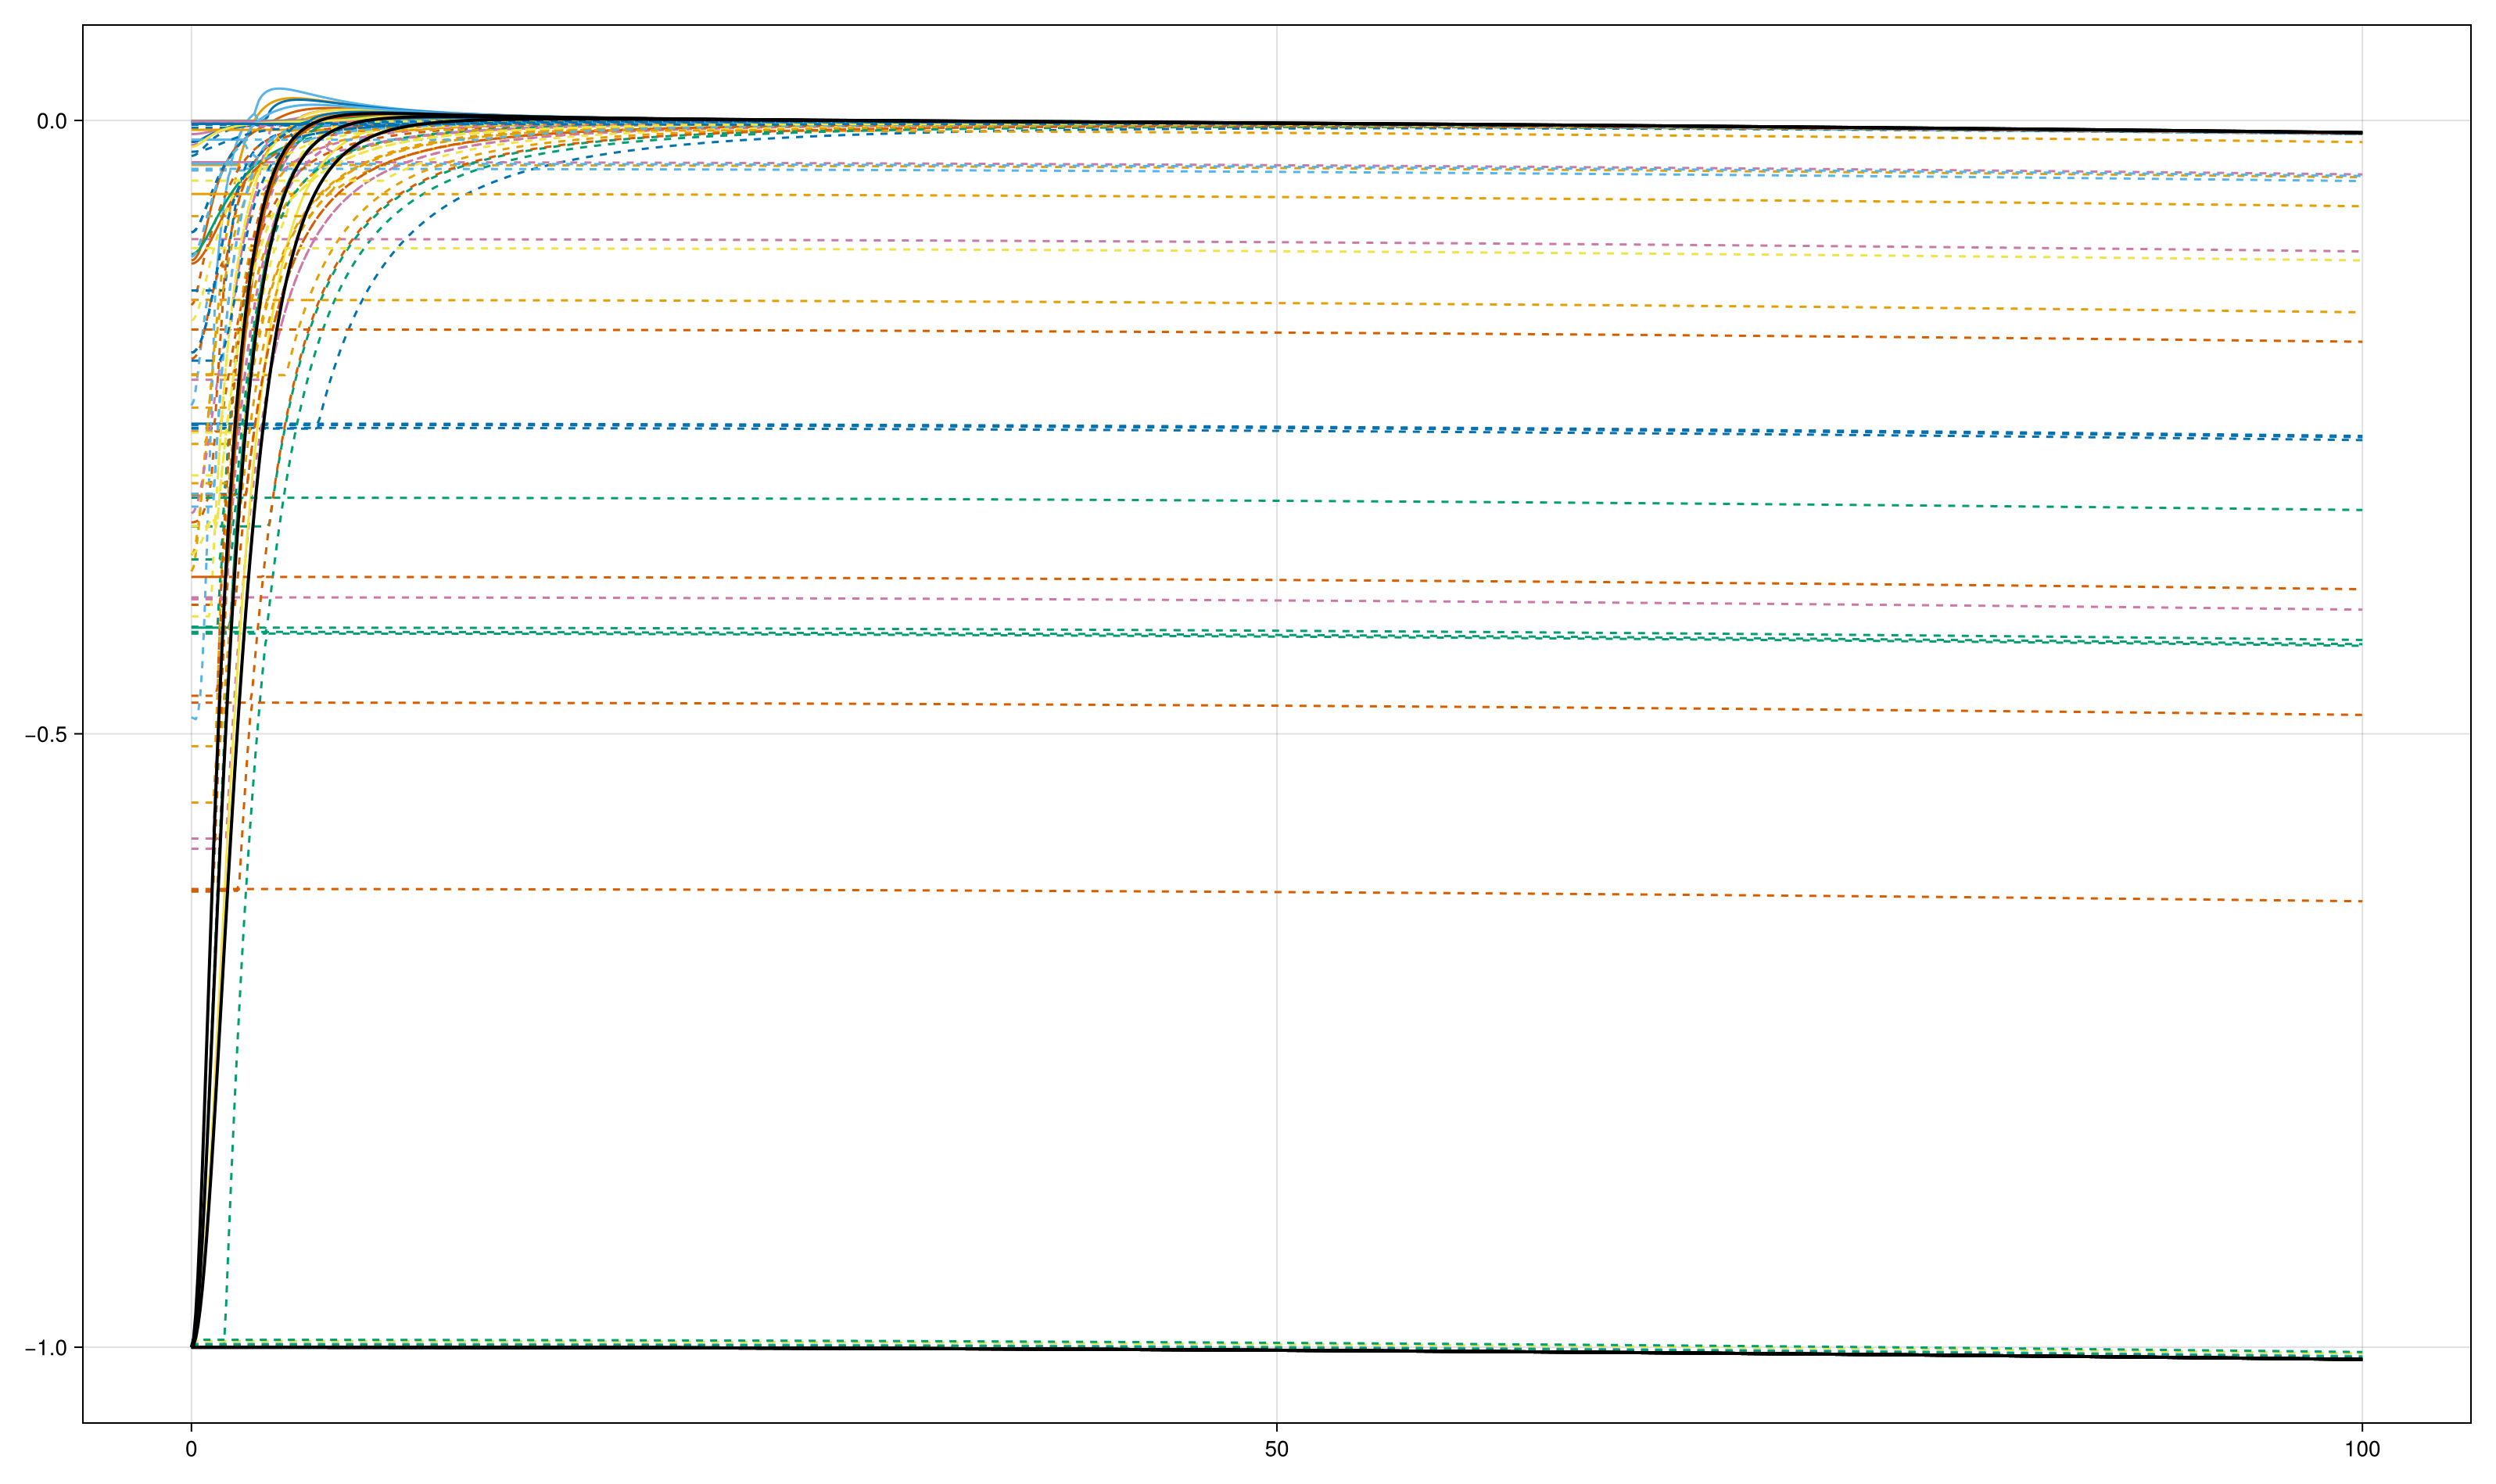

In [159]:
ks = range(0, 100, 1000)
num_evals = 5
# num_rows = 2
num_rows = nrow(sdf)

# MM lines
Ss = 1:10
tol = 1e-9
mm_Ds = [fmetadata.DN, 1., sdf.p[1]]
mm_u0 = [1., 0., 0.]

fig = Figure()
ax = Axis(fig[1,1])

for ri in 1:num_rows
    r = sdf[ri,:]
    xx = map(linstab_simple(r.params.mmicrm_params, r.params.Ds, r.ode_fs, ks; returnobj=:evals)) do evals
        real(evals[1:num_evals])
    end
    lines!(ax, ks, getindex.(xx, 1); color=Cycled(ri))
    if num_evals > 1
        for ii in 2:num_evals
            lines!(ax, ks, getindex.(xx, ii); color=Cycled(ri), linestyle=:dash)
        end
    end
end

for S in Ss
    mmp = MMParams(;
        K=sdf.K[1], l=sdf.l[1],
        m=1., c=1.,
        d=1 / S,
    );
    mm_ps = mmp_to_mmicrm(mmp; static=false)
    mm_p = make_mmicrm_problem(mm_ps, mm_u0, fmetadata.T)
    mm_s = solve(mm_p, QNDF();
        callback=make_timer_callback(10.),
        abstol=tol,
        reltol=tol,
    )
    mm_fs = mm_s.u[end];
    mresid = mmicrmmaxresid(mm_s)
    if (mresid > 1e-9) || (mm_fs[1] < 1e-9)
        @printf "S=%d, resid=%.5g, mm_fs[1]=%.5g\n" S mresid mm_fs[1]
    end

    mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)

    lines!(ax, ks, mm_mrls;
        color=:black,
        linewidth=2,
    )
end

display(GLMakie.Screen(), fig)

fig


d=0.289474, resid=5.9303e-26, mm_fs[1]=-5.8776e-32
d=0.250000, resid=7.6377e-26, mm_fs[1]=1.9175e-35


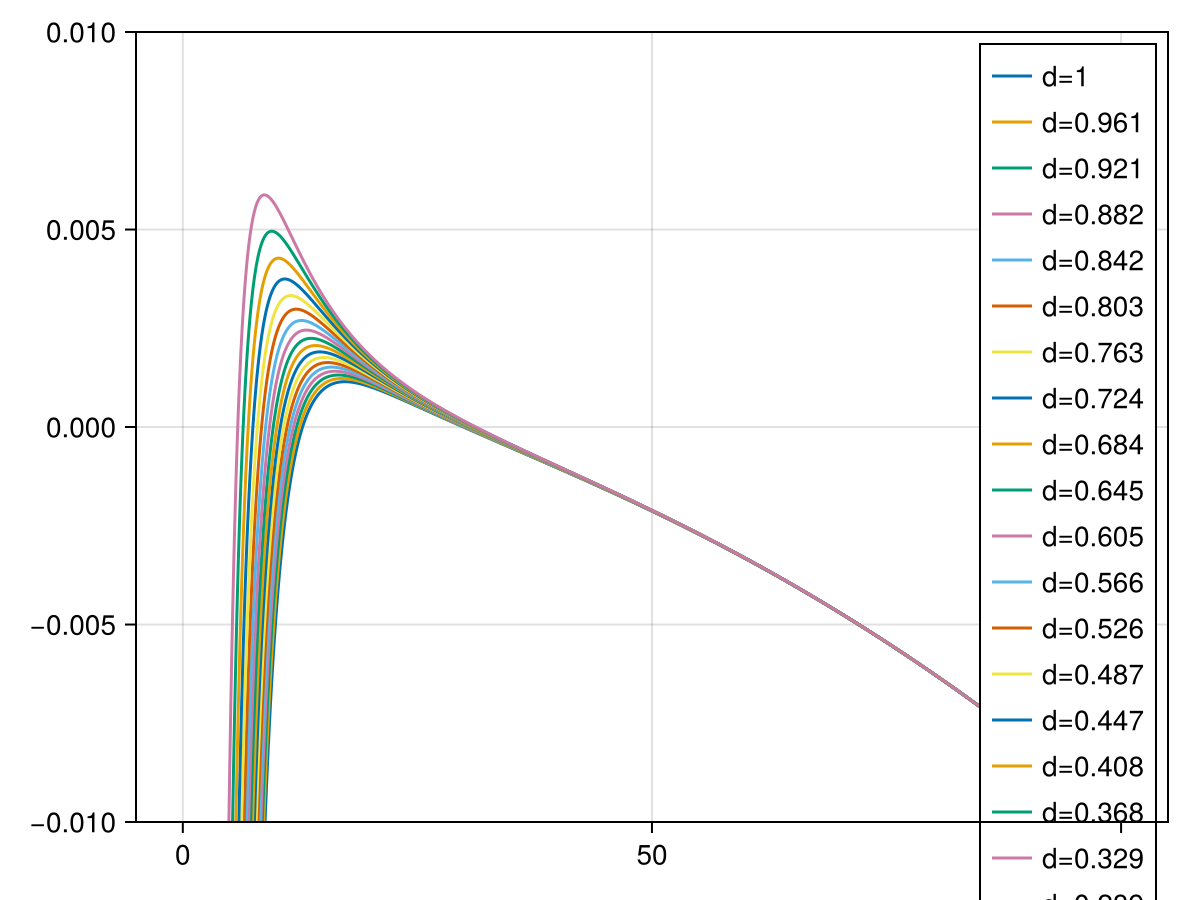

In [158]:
ks = range(0.01, 100, 1000)
# ds = 1 ./ (1:5)
ds = range(1., 0.25, 20)

tol = 1e-9

mm_Ds = [fmetadata.DN, 1., sdf.p[1]]
mm_u0 = [1., 0., 0.]

fig = Figure()
ax = Axis(fig[1,1])

for d in ds
    mmp = MMParams(;
        K=sdf.K[1], l=sdf.l[1],
        m=1., c=1.,
        d=d,
    );
    mm_ps = mmp_to_mmicrm(mmp; static=false)
    mm_p = make_mmicrm_problem(mm_ps, mm_u0, fmetadata.T)
    mm_s = solve(mm_p, QNDF();
        callback=make_timer_callback(10.),
        abstol=tol,
        reltol=tol,
    )
    mm_fs = mm_s.u[end];
    mresid = mmicrmmaxresid(mm_s)
    if (mresid > 1e-9) || (mm_fs[1] < 1e-9)
        @printf "d=%f, resid=%.5g, mm_fs[1]=%.5g\n" d mresid mm_fs[1]
    end

    mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)

    lines!(ax, ks, mm_mrls;
        label=(@sprintf "d=%.3g" d)
    )
end
axislegend(ax)

# display(GLMakie.Screen(), fig)
ylims!(ax, -0.01, 0.01)

fig
